# Model calibrations using ML

## Structure

# We apply the inverse map approach to solve the calibration problem

## Authors

Dr. Blanka Horvath, Aitor Muguruza Gonzalez, Mehdi Tomas

## Extract data

In [1]:
# replaced and takedn directly from https://github.com/amuguruza/NN-StochVol-Calibrations/blob/master/Heston/NNHeston.ipynb

import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
f = gzip.GzipFile('HestonTrainSet.txt.gz', "r")
dat=np.load(f)
xx=dat[:,:5]
yy=dat[:,5:]
print(xx.shape)
strikes=np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5 ])
maturities=np.array([0.1,0.3,0.6,0.9,1.2,1.5,1.8,2.0 ])

(12000, 5)


In [2]:
dat.shape

(12000, 93)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    yy, xx, test_size=0.15, random_state=42)
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
scale2=  StandardScaler()
y_train_transform = scale.fit_transform(y_train)
y_test_transform = scale.transform(y_test)
x_train_transform = scale2.fit_transform(X_train)
x_test_transform = scale2.transform(X_test)

In [4]:
strikes_dim=len(strikes)
maturities_dim=len(maturities)

# Convolutional nets

## We use a custom activation function to make sure that model parameters are within admisible bounds

### (No need to run the training optimal parameters are stored in a .h5 file)

In [5]:
import keras
from keras.layers import Activation
from keras.layers import Dense
from keras import backend as K

# Replaced depriciated version
# from keras.utils.generic_utils import get_custom_objects
from keras.saving import get_custom_objects
input1 = keras.layers.Input(shape=(len(maturities),len(strikes),1))
x1 = keras.layers.Convolution2D(16, (3, 3),activation='elu')(input1)
input2=keras.layers.Input(shape=(6,9, 16) )
x2=keras.layers.MaxPooling2D(pool_size=(2,2))(x1)
input3=keras.layers.Input(shape=(3,4, 16) )
x3=keras.layers.Flatten()(x2)
x4=keras.layers.Dense(50,activation = 'elu')(x3)

# [TODO] - ensure ordering is correct, taken from NNHeston
ub=scale.transform(np.array([[0.04,-0.1,1.0,0.2,10.0]]))[0]
lb=scale.transform(np.array([[0.0001,-0.95,0.01,0.01,1]]))[0]
def custom_activation1(x):
    return (keras.ops.tanh(x))*(ub[0] - lb[0]) *0.5 + (ub[0] + lb[0])*0.5
def custom_activation2(x):
    return (keras.ops.tanh(x))*(ub[1] - lb[1]) *0.5 + (ub[1] + lb[1])*0.5
def custom_activation3(x):
    # This line had an error, repla
    # return K.tanh(x)*(ub[2] - lb[2]) *0.5 + (ub[3] + lb[2])*0.5
    return keras.ops.tanh(x)*(ub[2] - lb[2]) *0.5 + (ub[2] + lb[2])*0.5
def custom_activation4(x):
    return keras.ops.tanh(x)*(ub[3] - lb[3]) *0.5 + (ub[3] + lb[3])*0.5
# Added custom_activation5
def custom_activation5(x):
    return keras.ops.tanh(x)*(ub[4] - lb[4]) *0.5 + (ub[4] + lb[4])*0.5

# get_custom_objects().update({'custom_activation1': Activation(custom_activation1)})
# get_custom_objects().update({'custom_activation2': Activation(custom_activation2)})
# get_custom_objects().update({'custom_activation3': Activation(custom_activation3)})
# get_custom_objects().update({'custom_activation4': Activation(custom_activation4)})
# Added this line below
# get_custom_objects().update({'custom_activation5': Activation(custom_activation5)})
seq1 = Dense(1, activation = custom_activation1)(x4)
seq2 = Dense(1, activation = custom_activation2)(x4)
seq3 = Dense(1, activation = custom_activation3)(x4)
seq4 = Dense(1, activation = custom_activation4)(x4)
# added seq5
seq5 = Dense(1, activation = custom_activation5)(x4)

# Added seq5
acum = keras.layers.concatenate([seq1, seq2, seq3,seq4,seq5], axis=-1)

model = keras.models.Model(inputs=input1, outputs=acum)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 11, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 6, 9, 16)  │        160 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 3, 4, 16)  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 192)       │          0 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │      9,650 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         51 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         51 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         51 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         51 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         51 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 5)         │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0],    │
│                     │                   │            │ dense_3[0][0],    │
│                     │                   │            │ dense_4[0][0],    │
│                     │                   │            │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,065 (39.32 KB)

 Trainable params: 10,065 (39.32 KB)

 Non-trainable params: 0 (0.00 B)

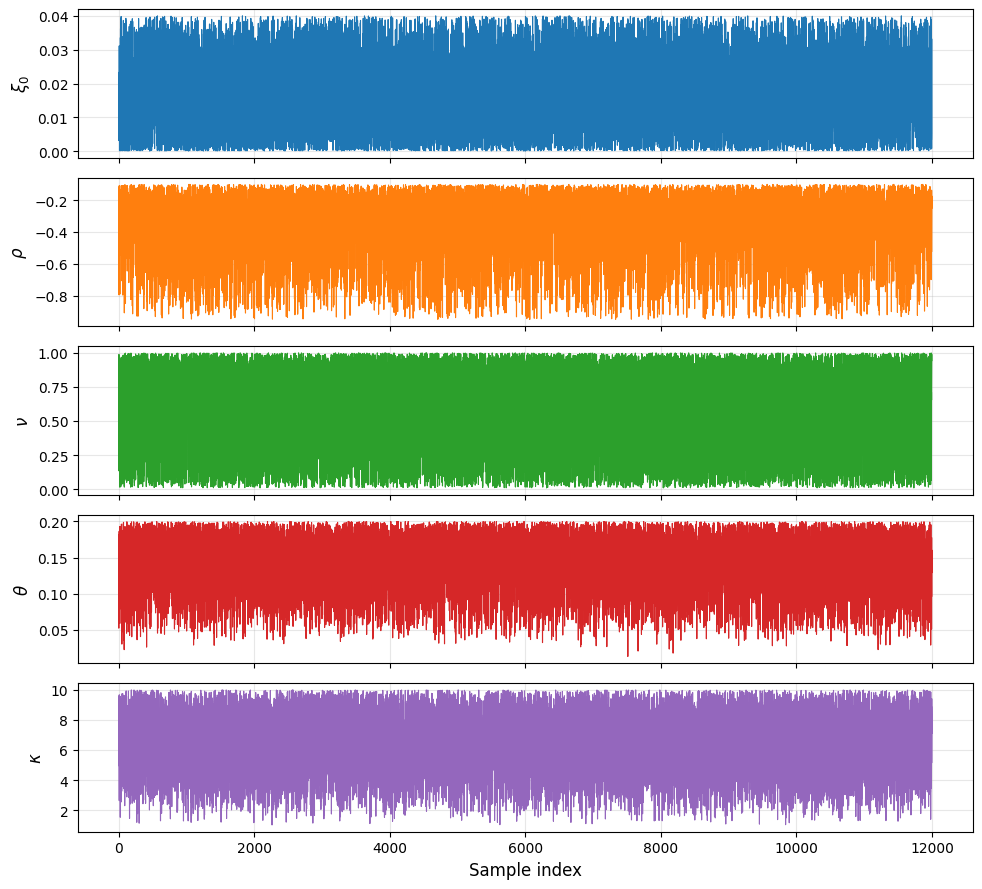

In [6]:
# Copy-paste this into the notebook (assumes `xx` is defined as dat[:,:5])
import matplotlib.pyplot as plt
import numpy as np

titles = [r'$\xi_0$', r'$\rho$', r'$\nu$', r'$\theta$', r'$\kappa$']
n_params = xx.shape[1]
fig, axes = plt.subplots(n_params, 1, figsize=(10, 9), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(np.arange(xx.shape[0]), xx[:, i], color='C{}'.format(i), lw=0.8)
    ax.set_ylabel(titles[i], fontsize=12)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Sample index', fontsize=12)
plt.tight_layout()
plt.show()

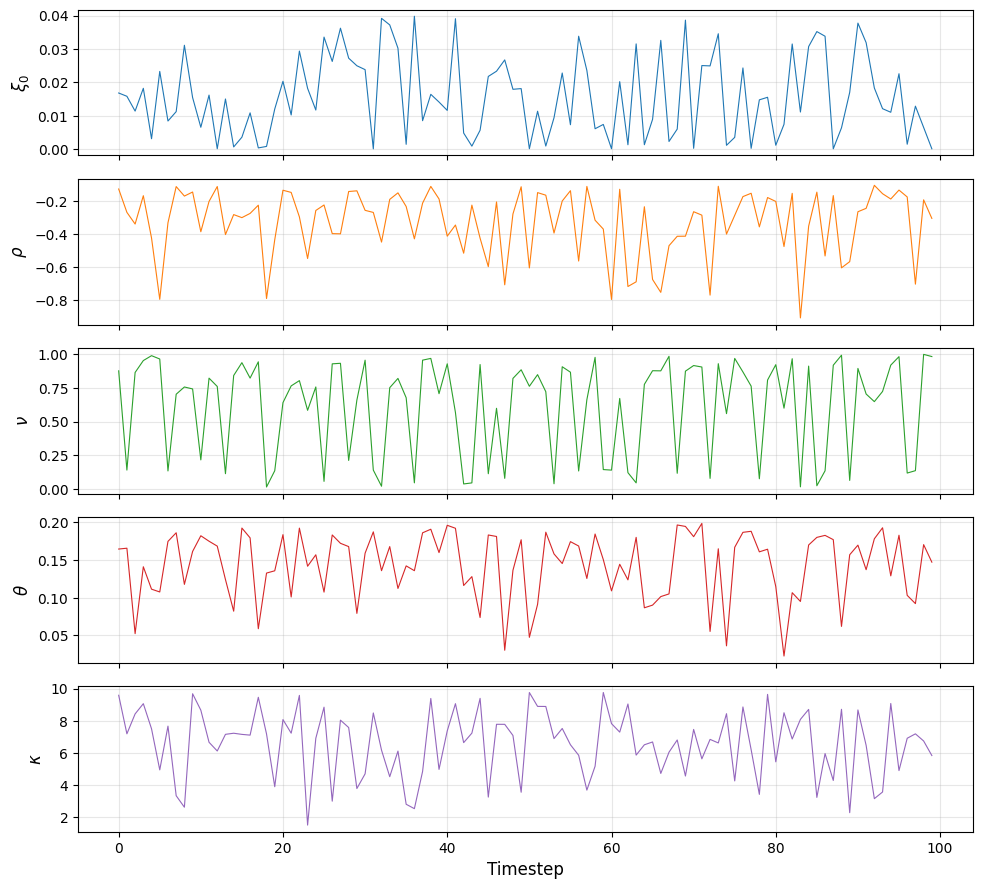

In [7]:
# Plot only the first 100 timesteps (or fewer if xx has less rows)

titles = [r'$\xi_0$', r'$\rho$', r'$\nu$', r'$\theta$', r'$\kappa$']
n_steps = 100
n = min(n_steps, xx.shape[0])
t = np.arange(n)

fig, axes = plt.subplots(len(titles), 1, figsize=(10, 9), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, xx[:n, i], color=f'C{i}', lw=0.8)
    ax.set_ylabel(titles[i], fontsize=12)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Timestep', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from keras.callbacks import EarlyStopping
# Configure Early Stopping
patience = 25
earlystop = EarlyStopping(monitor="val_loss",
                          min_delta=0,
                          mode="min",
                          verbose=1, 
                          patience=patience)
def root_mean_squared_error(y_true, y_pred):
        return keras.ops.sqrt(keras.ops.mean(keras.ops.square(y_pred - y_true)))
model.compile(loss = root_mean_squared_error, optimizer = "adam")
A=x_train_transform.reshape(len(x_train_transform),len(maturities),len(strikes),1)
B=x_test_transform.reshape(len(x_test_transform),len(maturities),len(strikes),1)
model.fit(A,y_train_transform, batch_size=64,validation_data = (B,y_test_transform),epochs = 200, verbose = True,shuffle=1,callbacks=[earlystop])

Epoch 1/200


In [ ]:
model.save_weights('HestonInverseMapNNWeights.weights.h5')

In [ ]:
model.save('HestonInverseMapNNModel.h5')

# Check relative errors per parameter

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━

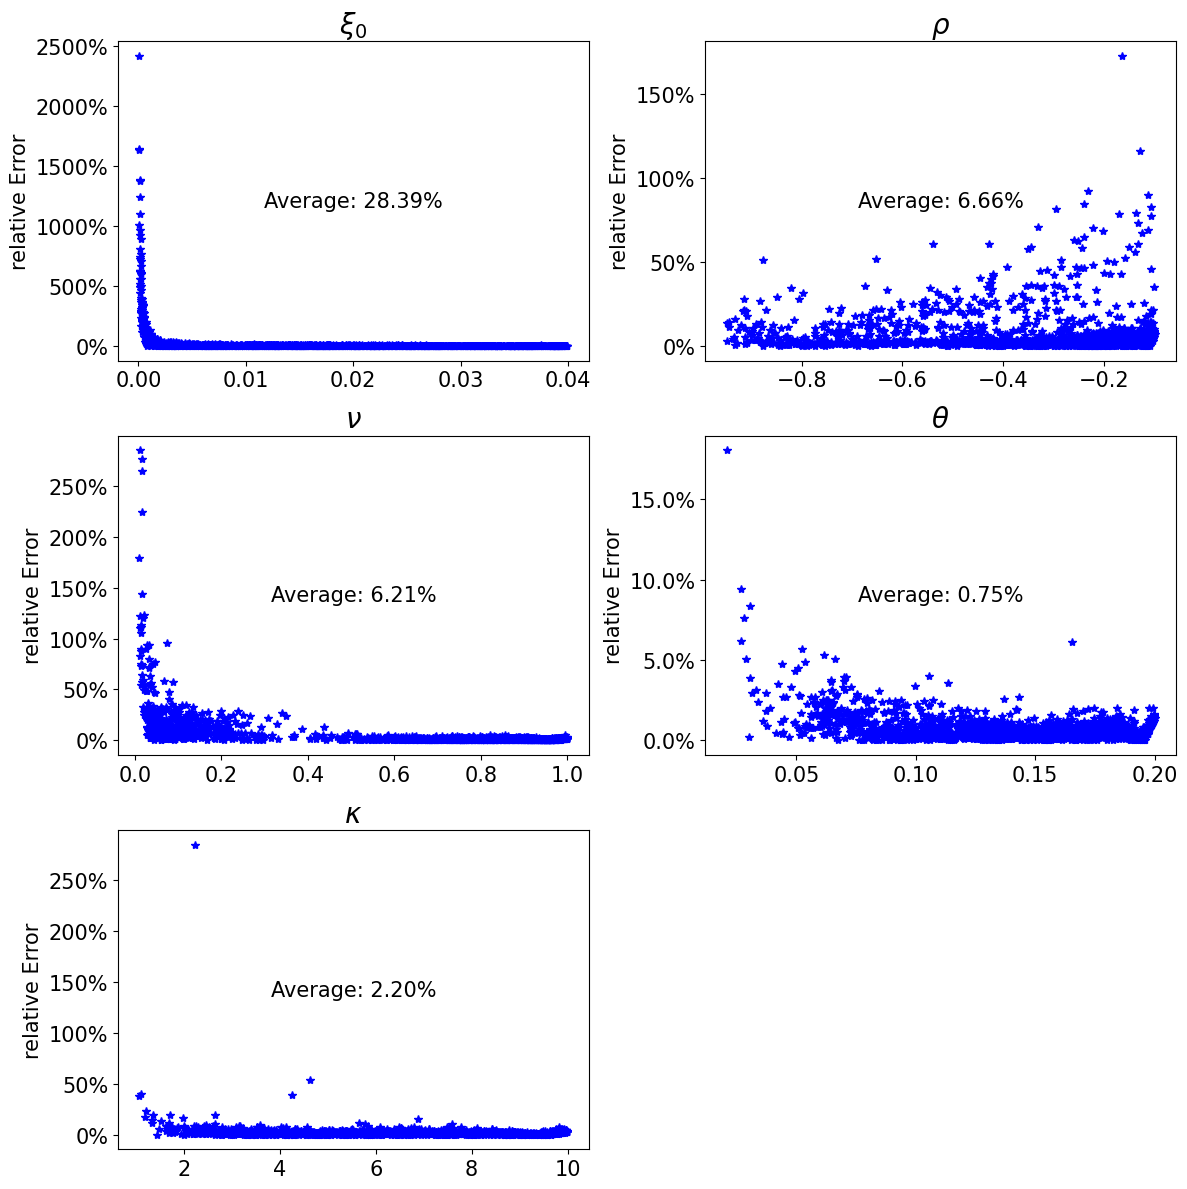

In [ ]:
import matplotlib.ticker as mtick
titles = ["$\\xi_0$", "$\\rho$", "$\\nu$", "$\\theta$", "$\\kappa$"]

n_test = len(y_test_transform)
average = np.zeros(n_test)
# average=np.zeros(5000)

fig=plt.figure(figsize=(12,12))


for u in range(5):
    # ax=plt.subplot(2,2,u+1)
    ax = plt.subplot(3,2,u+1)
    for i in range(n_test):
        # y=scale.inverse_transform(y_test_transform[i])[u]
        y = scale.inverse_transform(y_test_transform[i].reshape(1, -1))[0][u]
        approx=scale.inverse_transform(model.predict(x_test_transform[i].reshape(1,len(maturities),len(strikes),1)))[0][u]
        plt.plot(y,100*np.abs(approx-y)/np.abs(y),'b*')
        average[i]=np.abs(approx-y)/np.abs(y)
    plt.title(titles[u],fontsize=20)
    plt.ylabel('relative Error',fontsize=15)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter() )
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.tick_params(axis='both', which='minor', labelsize=15)
    plt.text(0.5, 0.5, 'Average: %1.2f%%'%np.mean(100*average), horizontalalignment='center',verticalalignment='center', transform=ax.transAxes,fontsize=15)

    print("average= ",np.mean(average))
plt.tight_layout()
plt.savefig('InverseMapRelativeErrors.png', dpi=300)
plt.show()